# Capstone Project 1: Working with NumPy Matrices (Multidimensional Data)

**Objective:** Analyse body measurement data from the National Health and Nutrition
Examination Survey (NHANES) for adult males and females, using NumPy for numerical
computation and Matplotlib/Seaborn for visualisation.


## 1. Setup and Imports

We begin by importing the libraries required for numerical computation
(`numpy`), statistical functions (`scipy.stats`), data visualisation
(`matplotlib`, `seaborn`), and light-weight tabular handling for the
pairplot (`pandas`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Consistent, professional plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 200

COLUMN_NAMES = [
    "weight_kg",
    "height_cm",
    "upper_arm_len_cm",
    "upper_leg_len_cm",
    "arm_circ_cm",
    "hip_circ_cm",
    "waist_circ_cm",
]


## 2. Loading the Data

The two CSV files are read directly into NumPy matrices named `male` and
`female`. Each file begins with a block of commented header lines (prefixed
with `#`) describing the data source, which `numpy.genfromtxt` is instructed
to skip via the `comments` argument. Each resulting matrix has 7 columns,
corresponding to weight, standing height, upper arm length, upper leg
length, arm circumference, hip circumference, and waist circumference,
with one row per survey participant.

In [3]:
male = np.genfromtxt("nhanes_adult_male_bmx_2020.csv", delimiter=",", comments="#")
female = np.genfromtxt("nhanes_adult_female_bmx_2020.csv", delimiter=",", comments="#")
print(male[0:5])
print(female[0:5])
print("The size of the file is",male.size,".And The shape of the file is",male.shape)
print("The size of the file is",female.size,".And The shape of the file is",female.shape)
print(np.isnan(male).sum())
print(np.isnan(female).sum())

[[  nan   nan   nan   nan   nan   nan   nan]
 [ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]
 [103.7 185.3  47.   44.   32.  107.8 109.6]
 [ 86.  167.8  39.5  38.4  29.  106.4 108.3]]
[[  nan   nan   nan   nan   nan   nan   nan]
 [ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]
 [ 61.7 157.4  38.   34.7  29.  101.   90.5]]
The size of the file is 28574 .And The shape of the file is (4082, 7)
The size of the file is 29554 .And The shape of the file is (4222, 7)
7
7


In [4]:
male = male[~np.isnan(male).any(axis=1)]
female = female[~np.isnan(female).any(axis=1)]

print("male matrix shape:",male.shape)
print("female matrix shape:",female.shape)


male matrix shape: (4081, 7)
female matrix shape: (4221, 7)


**Result:** The male matrix contains data for several thousand participants
across 7 measurement columns, and likewise for the female matrix. The shapes
confirm that both datasets were read correctly with 7 columns each, and that
we have a substantial sample size for statistical analysis.

## 3. Weight Distributions: Histograms

To compare how body weight is distributed between the two sexes, we plot
two histograms on a single figure using `plt.subplot`: the female
distribution on top and the male distribution below. To make the visual
comparison fair, we compute a shared x-axis range from the combined minimum
and maximum weight across both datasets and apply it to both subplots via
`plt.xlim`.

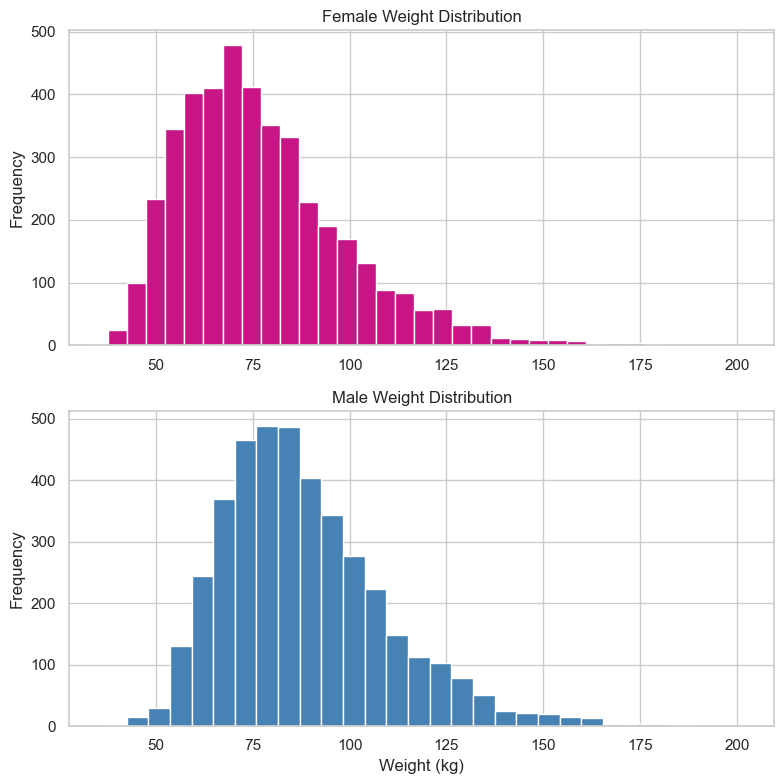

In [7]:
female_weight = female[:, 0]
male_weight = male[:, 0]

# Shared x-axis limits, with a small margin for readability
w_min = min(female_weight.min(), male_weight.min()) - 5
w_max = max(female_weight.max(), male_weight.max()) + 5

fig = plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.hist(female_weight, bins=30, color="mediumvioletred")
plt.xlim(w_min, w_max)
plt.title("Female Weight Distribution")
plt.ylabel("Frequency")

plt.subplot(2, 1, 2)
plt.hist(male_weight, bins=30, color="steelblue")
plt.xlim(w_min, w_max)
plt.title("Male Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


**Discussion:** Both distributions are unimodal and noticeably right-skewed,
meaning most participants cluster around a moderate weight while a smaller
number of considerably heavier individuals stretch the right tail. The male
distribution appears shifted to the right of the female distribution overall,
consistent with men typically carrying more body mass than women.

## 4. Weight Comparison: Box-and-Whisker Plot

A box plot summarises each distribution's median, interquartile range, and
outliers in a single compact shape, making it easy to compare male and
female weight side by side.

C:\Users\Acer\AppData\Local\Temp\ipykernel_14580\1010101052.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weight, male_weight], labels=["Female", "Male"])


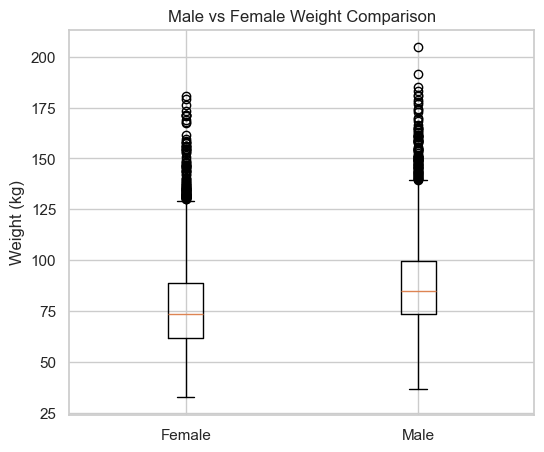

In [8]:
plt.figure(figsize=(6, 5))
plt.boxplot([female_weight, male_weight], labels=["Female", "Male"])
plt.ylabel("Weight (kg)")
plt.title("Male vs Female Weight Comparison")
plt.show()


**Discussion:** The male box sits noticeably higher than the female box,
confirming that men in this sample tend to weigh more on average. The male
distribution also appears to have a wider interquartile range, suggesting
greater variability in weight among men, while both groups show a number of
high-value outliers above the upper whisker, consistent with the right skew
observed in the histograms.

## 5. Basic Numerical Aggregates

We compute measures of location (mean, median), dispersion (standard
deviation, interquartile range), and shape (skewness, kurtosis) for both
weight columns.

In [9]:
def summarize(x, label):
    return {
        "group": label,
        "mean": np.mean(x),
        "median": np.median(x),
        "std": np.std(x, ddof=1),
        "IQR": np.percentile(x, 75) - np.percentile(x, 25),
        "min": np.min(x),
        "max": np.max(x),
        "skewness": stats.skew(x),
        "kurtosis": stats.kurtosis(x),
    }

summary_df = pd.DataFrame([
    summarize(female_weight, "Female"),
    summarize(male_weight, "Male"),
]).set_index("group").round(2)

summary_df


,mean,median,std,IQR,min,max,skewness,kurtosis
group,,,,,,,,
Female,77.40,73.6,21.55,27.1,32.6,180.9,1.03,1.40
Male,88.36,85.0,21.42,26.5,36.8,204.6,0.98,1.47


**Discussion:** The male mean and median weight both exceed the female
values, confirming men are heavier on average in this sample. The standard
deviation and IQR are also somewhat larger for males, indicating more
dispersion (variability) in male weight. Both groups show positive skewness,
meaning both distributions have a longer tail toward higher weights rather
than lower weights — i.e., both are right-skewed rather than left-skewed,
with a minority of heavier individuals pulling the mean above the median.

## 6. Adding Body Mass Index (BMI) to the Female Matrix

BMI is calculated as weight (kg) divided by the square of height (m). Since
height is stored in centimetres, we convert it to metres before computing
BMI, then append the result as an eighth column of the `female` matrix.

In [10]:
height_m = female[:, 1] / 100
bmi = female[:, 0] / (height_m ** 2)

female = np.column_stack([female, bmi])
COLUMN_NAMES_FEMALE = COLUMN_NAMES + ["bmi"]

print(f"female matrix shape after adding BMI: {female.shape}")
print(f"Sample BMI values: {np.round(female[:5, 7], 2)}")


female matrix shape after adding BMI: (4221, 8)
Sample BMI values: [37.84 39.07 28.09 24.9  23.18]


**Result:** The female matrix now has 8 columns, with BMI appended as the
final column. A quick look at the first few values shows plausible BMI
figures in the typical adult range.

## 7. Standardising the Female Matrix (Z-scores)

To make columns with different units and scales directly comparable, we
standardise every column of the female matrix by converting each value to
a z-score: subtracting the column mean and dividing by the column standard
deviation. The result, `zfemale`, has every column with mean 0 and standard
deviation 1.

In [11]:
(female - female.mean(axis=0)) / female.std(axis=0, ddof=1)

array([[ 9.14186775e-01,  8.94931852e-03, -5.67327418e-01, ...,
         1.08303325e+00,  1.11565244e+00,  9.96849600e-01],
       [ 6.35700670e-01, -1.05294368e+00, -1.07880364e+00, ...,
         1.04463152e+00,  2.65057592e-01,  1.15603786e+00],
       [-2.04399081e-01,  1.50535051e-01,  5.83494073e-01, ...,
        -1.90624297e-01, -3.72888546e-01, -2.59244296e-01],
       ...,
       [-2.04399081e-01, -7.60021211e-02,  7.20178550e-02, ...,
        -2.93028924e-01,  4.66616172e-02, -1.86258536e-01],
       [ 5.55212841e-02,  1.18411090e+00,  8.81855201e-01, ...,
        -4.33835286e-01,  6.83517123e-04, -3.11982694e-01],
       [ 2.50461558e-01, -1.74671377e+00, -5.24704400e-01, ...,
         7.82219661e-01,  6.61618705e-01,  1.00570034e+00]],
      shape=(4221, 8))

In [12]:
zfemale = (female - female.mean(axis=0)) / female.std(axis=0, ddof=1)

print("Column means after standardisation (should be ~0):")
print(np.round(zfemale.mean(axis=0), 4))
print("\nColumn std devs after standardisation (should be 1):")
print(np.round(zfemale.std(axis=0, ddof=1), 4))


Column means after standardisation (should be ~0):
[ 0.  0. -0. -0.  0. -0.  0. -0.]

Column std devs after standardisation (should be 1):
[1. 1. 1. 1. 1. 1. 1. 1.]


## 8. Scatterplot Matrix and Correlations (Standardised Female Data)

We examine the relationships between standardised height, weight, waist
circumference, hip circumference, and BMI using a pairplot, followed by
Pearson (linear) and Spearman (monotonic, rank-based) correlation
coefficients for every pair of variables.

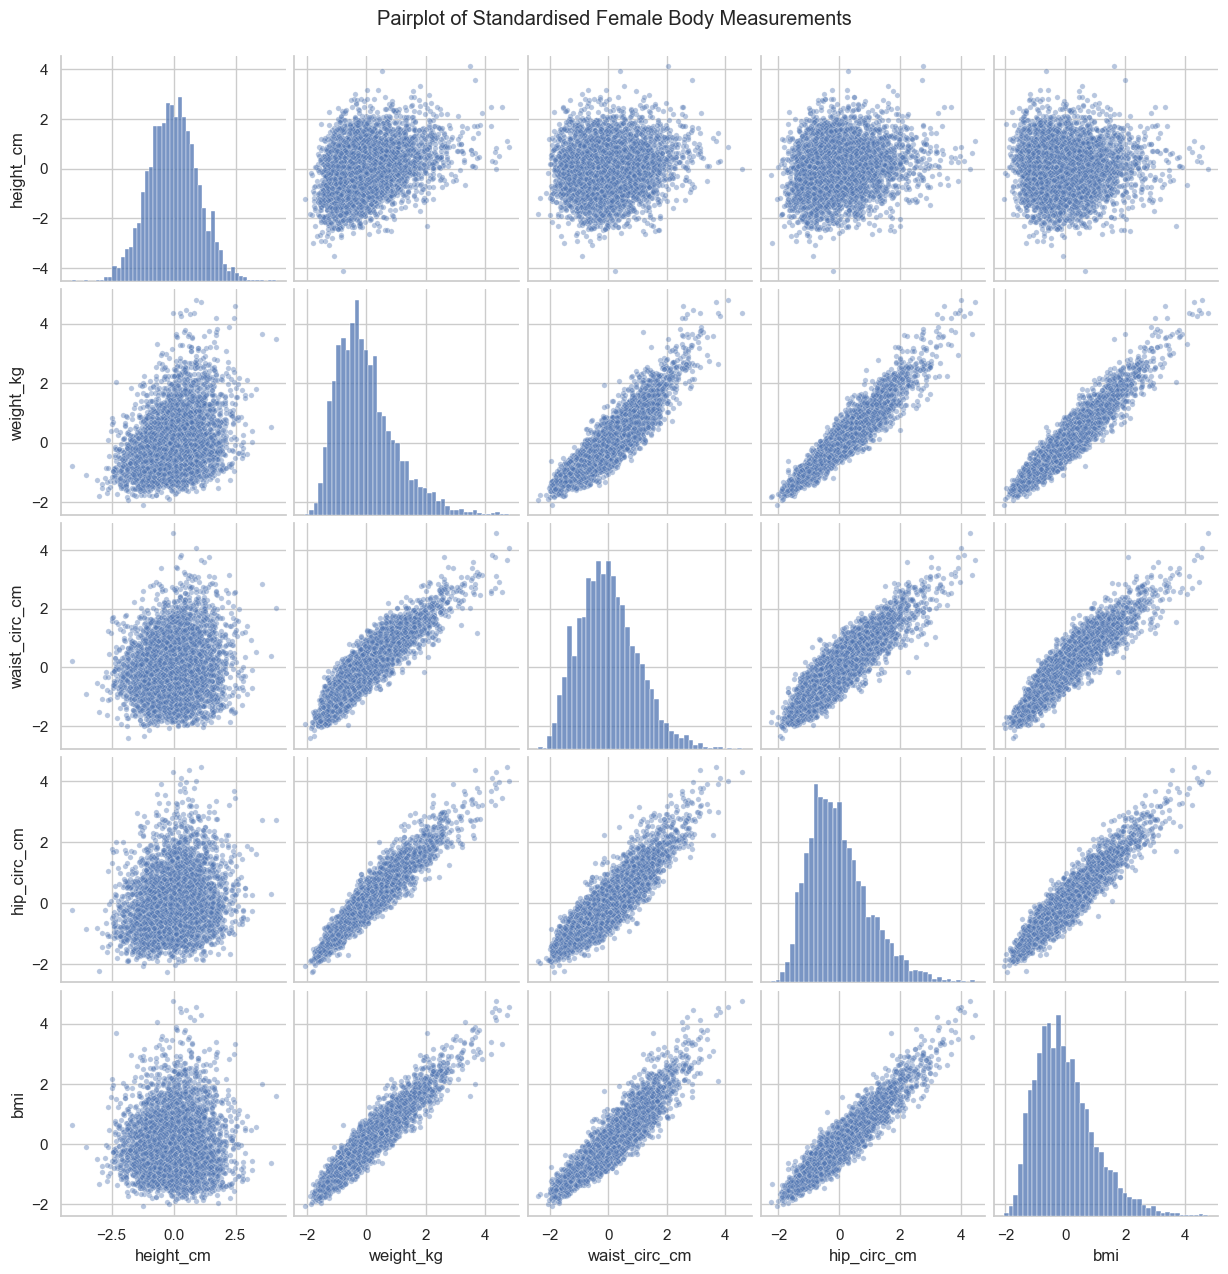

In [13]:
cols_of_interest = ["height_cm", "weight_kg", "waist_circ_cm", "hip_circ_cm", "bmi"]
idx = [COLUMN_NAMES_FEMALE.index(c) for c in cols_of_interest]

zfemale_subset = pd.DataFrame(zfemale[:, idx], columns=cols_of_interest)

sns.pairplot(zfemale_subset, diag_kind="hist", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pairplot of Standardised Female Body Measurements", y=1.02)
plt.show()


In [14]:
pearson_corr = zfemale_subset.corr(method="pearson").round(2)
spearman_corr = zfemale_subset.corr(method="spearman").round(2)

print("Pearson correlation matrix:")
display(pearson_corr)
print("\nSpearman correlation matrix:")
display(spearman_corr)


Pearson correlation matrix:


,height_cm,weight_kg,waist_circ_cm,hip_circ_cm,bmi
height_cm,1.00,0.35,0.13,0.20,0.03
weight_kg,0.35,1.00,0.90,0.95,0.95
waist_circ_cm,0.13,0.90,1.00,0.90,0.92
hip_circ_cm,0.20,0.95,0.90,1.00,0.94
bmi,0.03,0.95,0.92,0.94,1.00



Spearman correlation matrix:


,height_cm,weight_kg,waist_circ_cm,hip_circ_cm,bmi
height_cm,1.00,0.34,0.11,0.21,0.02
weight_kg,0.34,1.00,0.90,0.95,0.94
waist_circ_cm,0.11,0.90,1.00,0.89,0.92
hip_circ_cm,0.21,0.95,0.89,1.00,0.93
bmi,0.02,0.94,0.92,0.93,1.00


**Interpretation:** Weight shows a strong positive correlation with waist
circumference, hip circumference, and BMI, which is expected since all of
these reflect overall body size and adiposity. Height correlates positively
but more weakly with weight, and only weakly with BMI, which makes sense
because BMI is specifically constructed to normalise weight for height.
Waist and hip circumference are strongly correlated with each other, since
both track overall body size, but the correlation with BMI is stronger for
waist than for height, reinforcing that BMI is driven mainly by weight and
central body girth rather than by stature. Pearson and Spearman values are
similar in magnitude for most pairs, suggesting the relationships are
reasonably linear rather than merely monotonic curves.

## 9. Waist-to-Height and Waist-to-Hip Ratios

Two additional body-shape indicators are computed for both sexes: the
waist-to-height ratio and the waist-to-hip ratio. Each is appended as a new
column to the respective matrix.

In [15]:
def add_ratio_columns(matrix):
    waist = matrix[:, 6]
    height = matrix[:, 1]
    hip = matrix[:, 5]
    waist_to_height = waist / height
    waist_to_hip = waist / hip
    return np.column_stack([matrix, waist_to_height, waist_to_hip])

male = add_ratio_columns(male)
female = add_ratio_columns(female)

COLUMN_NAMES_MALE_FULL = COLUMN_NAMES + ["waist_to_height", "waist_to_hip"]
COLUMN_NAMES_FEMALE_FULL = COLUMN_NAMES_FEMALE + ["waist_to_height", "waist_to_hip"]

print(f"male matrix shape:   {male.shape}")
print(f"female matrix shape: {female.shape}")


male matrix shape:   (4081, 9)
female matrix shape: (4221, 10)


## 10. Comparing the Four Ratio Distributions

A single box plot with four boxes lets us compare waist-to-height and
waist-to-hip ratios across both sexes simultaneously.

C:\Users\Acer\AppData\Local\Temp\ipykernel_14580\3037143423.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


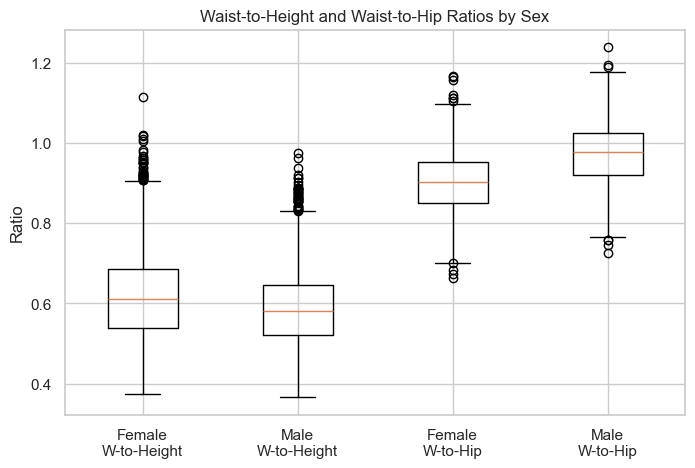

In [16]:
male_wth = male[:, -2]
female_wth = female[:, -2]
male_whr = male[:, -1]
female_whr = female[:, -1]

plt.figure(figsize=(8, 5))
plt.boxplot(
    [female_wth, male_wth, female_whr, male_whr],
    labels=["Female\nW-to-Height", "Male\nW-to-Height", "Female\nW-to-Hip", "Male\nW-to-Hip"],
)
plt.ylabel("Ratio")
plt.title("Waist-to-Height and Waist-to-Hip Ratios by Sex")
plt.show()


**Discussion:** Waist-to-height ratios are fairly similar between males
and females and cluster in a comparable range, with many participants near
or above the commonly cited 0.5 health-risk threshold. Waist-to-hip ratio,
in contrast, tends to be noticeably higher for males than for females,
reflecting the more common "apple-shaped" (central) fat distribution in men
compared to the more "pear-shaped" (hip/thigh) distribution typical in
women.

## 11. BMI vs. Waist-to-Height vs. Waist-to-Hip: Advantages and Disadvantages

- **BMI**
  - *Advantages:* Extremely simple to calculate from just height and weight; widely
    used and understood; useful for population-level screening.
  - *Disadvantages:* Does not distinguish muscle from fat, nor where fat is
    stored; can misclassify muscular individuals as overweight and can
    underestimate risk in people with normal weight but high abdominal fat.

- **Waist-to-Height Ratio**
  - *Advantages:* Directly reflects central/abdominal obesity, which is more
    strongly linked to cardiometabolic risk than total body weight; a single
    simple threshold (around 0.5) applies reasonably well across sexes and
    heights.
  - *Disadvantages:* Waist measurement is less standardised in practice (the
    exact landmark used can vary), and it still does not capture fat versus
    muscle composition.

- **Waist-to-Hip Ratio**
  - *Advantages:* Captures body-shape (apple vs. pear) information that BMI
    cannot, and is a good indicator of central obesity relative to overall
    frame.
  - *Disadvantages:* Two people with very different absolute body sizes can
    have the same ratio; requires two measurements (more room for measurement
    error) and lacks the extensive historical reference data that BMI has
    accumulated.

## 12. Extremes of BMI: Lowest and Highest 5 Participants

Using `numpy.argsort` on the female BMI column, we identify the 5
participants with the lowest BMI and the 5 with the highest BMI, then print
their full standardised (z-score) measurements from `zfemale`.

In [18]:
bmi_col_idx = COLUMN_NAMES_FEMALE.index("bmi")
sorted_idx = np.argsort(female[:, bmi_col_idx])

lowest_5_idx = sorted_idx[:5]
highest_5_idx = sorted_idx[-5:]

extremes_df = pd.DataFrame(
    zfemale[np.concatenate([lowest_5_idx, highest_5_idx]), :],
    columns=COLUMN_NAMES_FEMALE,
    index=[f"low_{i+1}" for i in range(5)] + [f"high_{i+1}" for i in range(5)],
).round(2)

extremes_df

,weight_kg,height_cm,upper_arm_len_cm,upper_leg_len_cm,arm_circ_cm,hip_circ_cm,waist_circ_cm,bmi
low_1,-2.08,-1.22,-1.55,-1.17,-2.19,-2.04,-1.94,-2.05
low_2,-1.88,-0.19,-1.72,0.39,-2.44,-1.85,-2.06,-1.99
low_3,-1.54,1.81,0.63,0.57,-2.27,-1.68,-1.71,-1.97
low_4,-1.84,-0.26,-0.23,0.51,-2.30,-2.25,-1.86,-1.94
low_5,-1.61,0.89,-0.10,0.48,-2.21,-1.83,-1.71,-1.89
high_1,4.25,0.29,1.86,-0.98,2.37,4.10,3.82,4.40
high_2,4.46,0.50,1.69,-1.14,3.35,3.98,2.90,4.46
high_3,4.35,0.28,2.84,1.94,4.37,3.92,3.75,4.51
high_4,4.80,0.89,2.12,1.82,3.78,4.02,4.08,4.54
high_5,4.36,-0.03,-0.06,-0.17,2.78,4.32,4.57,4.76


**Interpretation:** The five lowest-BMI participants show consistently
negative z-scores across weight, waist circumference, hip circumference,
and BMI itself, indicating these individuals are slimmer than average on
essentially every related measurement, not just BMI in isolation. The five
highest-BMI participants show the opposite pattern, with strongly positive
z-scores for weight, waist, and hip circumference. Interestingly, height
z-scores are much closer to zero and show no clear pattern across either
extreme group, confirming that BMI extremes are driven primarily by weight
and body girth rather than by how tall or short a participant is.

## Conclusion

This analysis compared body measurements between adult male and female
NHANES participants. Males were found to have higher average weight and
waist-to-hip ratio, while waist-to-height ratios were broadly similar
between sexes. Correlation analysis of standardised female measurements
confirmed that weight, waist circumference, hip circumference, and BMI are
strongly interrelated, while height plays a comparatively minor role in
determining BMI extremes. Each body-shape metric examined—BMI,
waist-to-height ratio, and waist-to-hip ratio—offers a different lens on
body composition and carries its own strengths and limitations, suggesting
that a combination of these measures gives a more complete health picture
than any single metric alone.